Measured P_ee = 0.3458 ± 0.0374
Best-fit θ₁₂  = 36.02° ± 2.25°
PDG SNO-only  ≈ 36°  (pre-KamLAND)
PDG combined  = 33.4° (post-KamLAND)


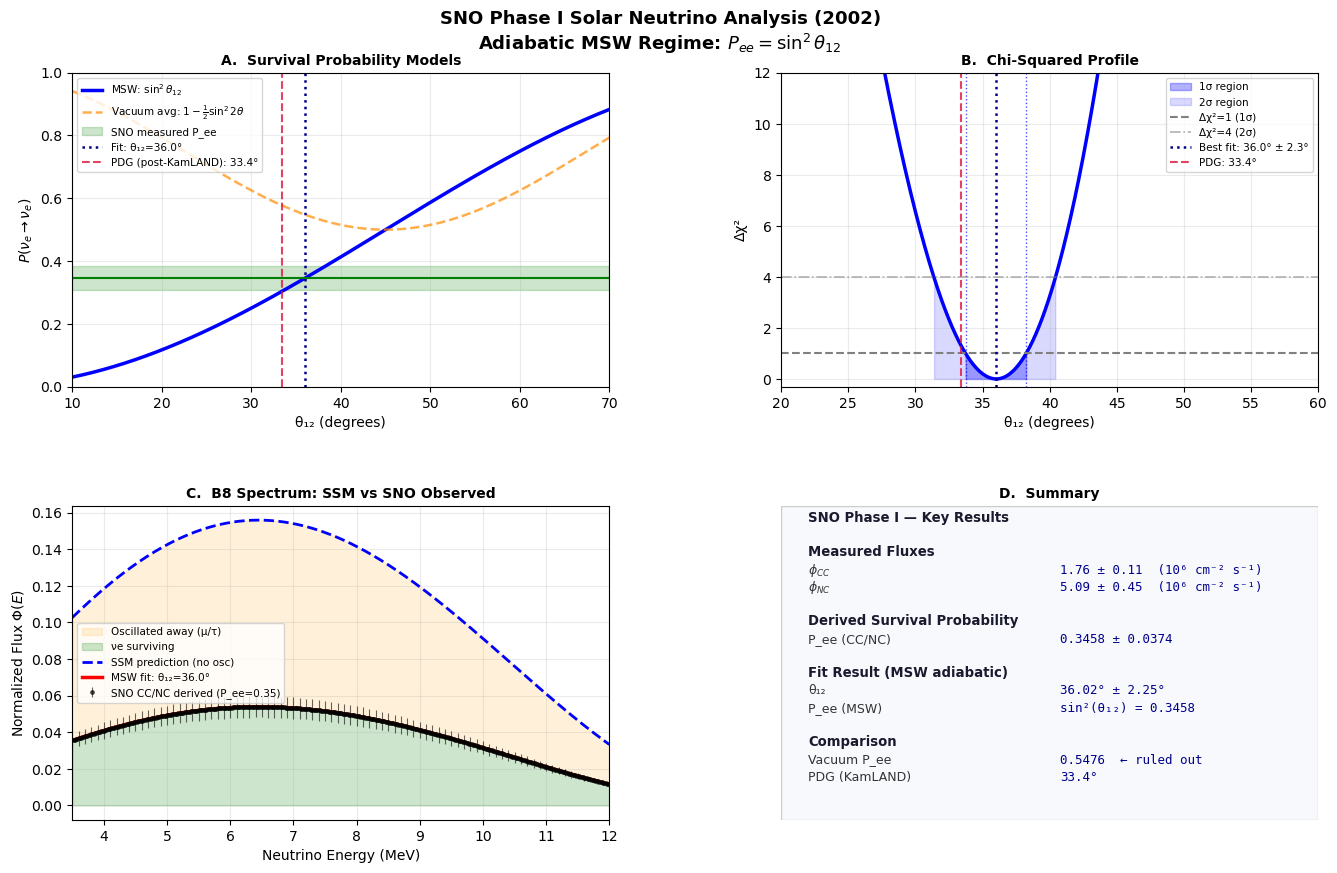

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import brentq
 
# ── 1. SNO Phase I experimental inputs (2002 paper) ──────────────────────────
phi_cc_val, phi_cc_err = 1.76, 0.11   # 10^6 cm^-2 s^-1
phi_nc_val, phi_nc_err = 5.09, 0.45
 
p_ee_obs = phi_cc_val / phi_nc_val
p_ee_err = p_ee_obs * np.sqrt((phi_cc_err/phi_cc_val)**2 + (phi_nc_err/phi_nc_val)**2)
 
print(f"Measured P_ee = {p_ee_obs:.4f} ± {p_ee_err:.4f}")
 
# ── 2. Fit: sin²(θ) = p_ee_obs  →  θ = arcsin(√p_ee_obs) ──────────────────
def p_ee_msw(theta_deg):
    return np.sin(np.deg2rad(theta_deg))**2
 
best_theta = np.degrees(np.arcsin(np.sqrt(p_ee_obs)))
 
# Uncertainty via error propagation: dθ/dP_ee = 1/(2 sin(θ)cos(θ)) = 1/sin(2θ)
dtheta_dPee = 1.0 / np.sin(2 * np.deg2rad(best_theta))
theta_err   = np.degrees(dtheta_dPee * p_ee_err)
 
print(f"Best-fit θ₁₂  = {best_theta:.2f}° ± {theta_err:.2f}°")
print(f"PDG SNO-only  ≈ 36°  (pre-KamLAND)")
print(f"PDG combined  = 33.4° (post-KamLAND)")
 
# ── 3. Load B8 spectrum ───────────────────────────────────────────────────────
df   = pd.read_csv('b8spectrum.csv')
mask = (df['E_MeV'] >= 3.5) & (df['E_MeV'] <= 12.0)
E    = df['E_MeV'][mask].values
phi  = df['flux'][mask].values
phi  = phi / np.trapezoid(phi, E)
 
# ── 4. Chi-squared profile for the single P_ee measurement ───────────────────
def chi2_single(theta_deg):
    """Single-point chi2 from the CC/NC ratio measurement"""
    return ((p_ee_msw(theta_deg) - p_ee_obs) / p_ee_err)**2
 
theta_scan = np.linspace(15, 65, 2000)
chi2_scan  = np.array([chi2_single(t) for t in theta_scan])
chi2_min   = chi2_single(best_theta)
 
# 1-sigma and 2-sigma crossings
try:
    lo1 = brentq(lambda t: chi2_single(t) - (chi2_min+1), 15, best_theta)
    hi1 = brentq(lambda t: chi2_single(t) - (chi2_min+1), best_theta, 65)
    lo2 = brentq(lambda t: chi2_single(t) - (chi2_min+4), 15, best_theta)
    hi2 = brentq(lambda t: chi2_single(t) - (chi2_min+4), best_theta, 65)
except:
    lo1, hi1, lo2, hi2 = None, None, None, None
 
# ── 5. Figure layout ──────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 9))
gs  = gridspec.GridSpec(2, 2, hspace=0.38, wspace=0.32,
                        left=0.08, right=0.97, top=0.91, bottom=0.08)
 
fig.suptitle("SNO Phase I Solar Neutrino Analysis (2002)\n"
             "Adiabatic MSW Regime: $P_{ee} = \\sin^2\\theta_{12}$",
             fontsize=13, fontweight='bold', y=0.98)
 
# ─ Panel A: P_ee model vs theta with measurement band ────────────────────────
ax0 = fig.add_subplot(gs[0, 0])
 
theta_plot = np.linspace(10, 70, 500)
ax0.plot(theta_plot, p_ee_msw(theta_plot), 'b-', lw=2.5,
         label=r'MSW: $\sin^2\theta_{12}$')
ax0.plot(theta_plot, 1 - 0.5*np.sin(2*np.deg2rad(theta_plot))**2,
         color='darkorange', ls='--', lw=1.8, alpha=0.7,
         label=r'Vacuum avg: $1-\frac{1}{2}\sin^2 2\theta$')
 
# Measured P_ee band
ax0.axhspan(p_ee_obs - p_ee_err, p_ee_obs + p_ee_err,
            alpha=0.20, color='green', label=f'SNO measured P_ee')
ax0.axhline(p_ee_obs, color='green', lw=1.5, ls='-')
 
# Best fit angle
ax0.axvline(best_theta, color='darkblue', ls=':', lw=1.8,
            label=f'Fit: θ₁₂={best_theta:.1f}°')
ax0.axvline(33.4, color='crimson', ls='--', lw=1.5, alpha=0.8,
            label='PDG (post-KamLAND): 33.4°')
 
ax0.set_xlim(10, 70)
ax0.set_ylim(0, 1)
ax0.set_xlabel('θ₁₂ (degrees)', fontsize=10)
ax0.set_ylabel('$P(\\nu_e \\to \\nu_e)$', fontsize=10)
ax0.set_title('A.  Survival Probability Models', fontsize=10, fontweight='bold')
ax0.legend(fontsize=7.5, loc='upper left')
ax0.grid(alpha=0.25)
 
# ─ Panel B: Chi-squared profile ───────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 1])
 
ax1.plot(theta_scan, chi2_scan - chi2_min, 'b-', lw=2.5)
 
# Fill 1σ and 2σ regions
if lo1:
    ax1.fill_between(theta_scan, 0, chi2_scan - chi2_min,
                     where=(theta_scan >= lo1) & (theta_scan <= hi1),
                     alpha=0.30, color='blue', label='1σ region')
    ax1.fill_between(theta_scan, 0, chi2_scan - chi2_min,
                     where=(theta_scan >= lo2) & (theta_scan <= hi2),
                     alpha=0.15, color='blue', label='2σ region')
    ax1.axvline(lo1, color='blue', ls=':', lw=1, alpha=0.7)
    ax1.axvline(hi1, color='blue', ls=':', lw=1, alpha=0.7)
 
ax1.axhline(1.0, color='gray', ls='--', lw=1.5, label='Δχ²=1 (1σ)')
ax1.axhline(4.0, color='gray', ls='-.', lw=1.2, alpha=0.6, label='Δχ²=4 (2σ)')
ax1.axvline(best_theta, color='darkblue', ls=':', lw=1.8,
            label=f'Best fit: {best_theta:.1f}° ± {theta_err:.1f}°')
ax1.axvline(33.4, color='crimson', ls='--', lw=1.5, alpha=0.8,
            label='PDG: 33.4°')
 
ax1.set_xlim(20, 60)
ax1.set_ylim(-0.3, 12)
ax1.set_xlabel('θ₁₂ (degrees)', fontsize=10)
ax1.set_ylabel('Δχ²', fontsize=10)
ax1.set_title('B.  Chi-Squared Profile', fontsize=10, fontweight='bold')
ax1.legend(fontsize=7.5)
ax1.grid(alpha=0.25)
 
# ─ Panel C: Spectrum showing suppression ──────────────────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
 
# Shade between SSM and observed to visualise the "missing" neutrinos
ax2.fill_between(E, p_ee_msw(best_theta)*phi, phi,
                 alpha=0.15, color='orange', label='Oscillated away (μ/τ)')
ax2.fill_between(E, 0, p_ee_msw(best_theta)*phi,
                 alpha=0.20, color='green', label='νe surviving')
 
ax2.plot(E, phi, 'b--', lw=2, label='SSM prediction (no osc)')
ax2.errorbar(E, p_ee_obs*phi, yerr=p_ee_err*phi,
             fmt='ko', ms=2.5, lw=0.8, alpha=0.6, errorevery=5,
             label=f'SNO CC/NC derived (P_ee={p_ee_obs:.2f})')
ax2.plot(E, p_ee_msw(best_theta)*phi, 'r-', lw=2.5,
         label=f'MSW fit: θ₁₂={best_theta:.1f}°')
 
ax2.set_xlabel('Neutrino Energy (MeV)', fontsize=10)
ax2.set_ylabel('Normalized Flux $\\Phi(E)$', fontsize=10)
ax2.set_title('C.  B8 Spectrum: SSM vs SNO Observed', fontsize=10, fontweight='bold')
ax2.legend(fontsize=7.5)
ax2.grid(alpha=0.25)
ax2.set_xlim(3.5, 12)
 
# ─ Panel D: Summary results box ───────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')
 
vacuum_Pee = 1 - 0.5*np.sin(2*np.deg2rad(best_theta))**2
summary = [
    ("SNO Phase I — Key Results", "", True),
    ("", "", False),
    ("Measured Fluxes", "", True),
    (r"$\phi_{CC}$",  f"{phi_cc_val} ± {phi_cc_err}  (10⁶ cm⁻² s⁻¹)", False),
    (r"$\phi_{NC}$",  f"{phi_nc_val} ± {phi_nc_err}  (10⁶ cm⁻² s⁻¹)", False),
    ("", "", False),
    ("Derived Survival Probability", "", True),
    ("P_ee (CC/NC)",  f"{p_ee_obs:.4f} ± {p_ee_err:.4f}", False),
    ("", "", False),
    ("Fit Result (MSW adiabatic)", "", True),
    ("θ₁₂",          f"{best_theta:.2f}° ± {theta_err:.2f}°", False),
    ("P_ee (MSW)",    f"sin²(θ₁₂) = {p_ee_msw(best_theta):.4f}", False),
    ("", "", False),
    ("Comparison", "", True),
    ("Vacuum P_ee",   f"{vacuum_Pee:.4f}  ← ruled out", False),
    ("PDG (KamLAND)", "33.4°", False),
]
 
y = 0.95
for label, value, bold in summary:
    if bold:
        ax3.text(0.05, y, label, transform=ax3.transAxes,
                 fontsize=9.5, fontweight='bold', color='#1a1a2e')
    elif label == "":
        pass
    else:
        ax3.text(0.05, y, label, transform=ax3.transAxes, fontsize=9, color='#333')
        ax3.text(0.52, y, value, transform=ax3.transAxes, fontsize=9,
                 color='darkblue', fontfamily='monospace')
    y -= 0.055
 
ax3.set_title('D.  Summary', fontsize=10, fontweight='bold')
ax3.add_patch(plt.Rectangle((0, 0), 1, 1, fill=True,
              facecolor='#f7f9fc', edgecolor='#cccccc', lw=1,
              transform=ax3.transAxes, zorder=0))
 
plt.savefig('sno_msw_analysis.png', dpi=200, bbox_inches='tight')
plt.show()